HydroSense-Kenya: System Integration and Final Simulation
Level 6: Master Pipeline Execution

This notebook acts as the master control center. It integrates the robust data cleaning pipeline with our custom numerical methods engine to establish dynamic environmental thresholds, and visualizes the final operational intelligence of the smart irrigation network.
1. Engine Initialization & Data Ingestion

Connecting the customized modules and importing the raw data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Connect the notebook to our custom backend engine
sys.path.append(os.path.abspath("../src"))
from data_cleaning import process_pipeline
from numerical_methods import bisection_method

# Execute the master data pipeline (Handles Level 1 Ingestion & Level 4 Cleaning)
print("--- Booting HydroSense-Kenya Master Pipeline ---")
system_data = process_pipeline()
print(f"Data successfully processed. Total operational records: {len(system_data)}")

# Display the final, pristine dataset ready for simulation
display(system_data.head())

--- Booting HydroSense-Kenya Master Pipeline ---
Data successfully processed. Total operational records: 90


,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01 12:00:00,Zone_A,33.2,4829.0,18.8,437,OK,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02 12:00:00,Zone_A,36.1,4757.0,16.6,411,OK,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03 12:00:00,Zone_A,33.7,4791.0,17.1,438,OK,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04 12:00:00,Zone_A,31.8,4704.0,17.5,444,OK,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05 12:00:00,Zone_A,33.3,4836.0,16.5,438,OK,2026-03-05,23.7,26.6,61.0,1.36,0.62


2. Establishing Dynamic Thresholds (Numerical Methods)

Instead of hardcoding a static temperature limit, the system dynamically calculates the exact critical temperature at which Evapotranspiration (ET) exceeds the crop survival rate, given current baseline wind, solar, and humidity conditions.

In [2]:
# Fixed baseline environmental parameters for the simulation day
W, S, H = 2.5, 0.7, 65.0
critical_et = 6.0

# Define the target function mapped to the mathematical model
def et_target_func(T):
    return (0.12 * T) + (0.35 * W) + (2.4 * S) - (0.025 * H) - critical_et

# Utilize our validated custom Bisection Algorithm from Level 3
root_bisect, iters, err, status = bisection_method(et_target_func, a=10, b=50)

print("--- System Threshold Computed ---")
print(f"Algorithm Status: {status} (in {iters} iterations)")
print(f"Calculated Critical Temperature Threshold: {root_bisect:.2f} °C")

--- System Threshold Computed ---
Algorithm Status: Converged (in 17 iterations)
Calculated Critical Temperature Threshold: 42.25 °C


3. Master System Dashboard

Visualizing the full operational state of the farm. This composite dashboard overlays our mathematically derived thresholds against real-world atmospheric drivers and subsurface soil responses.

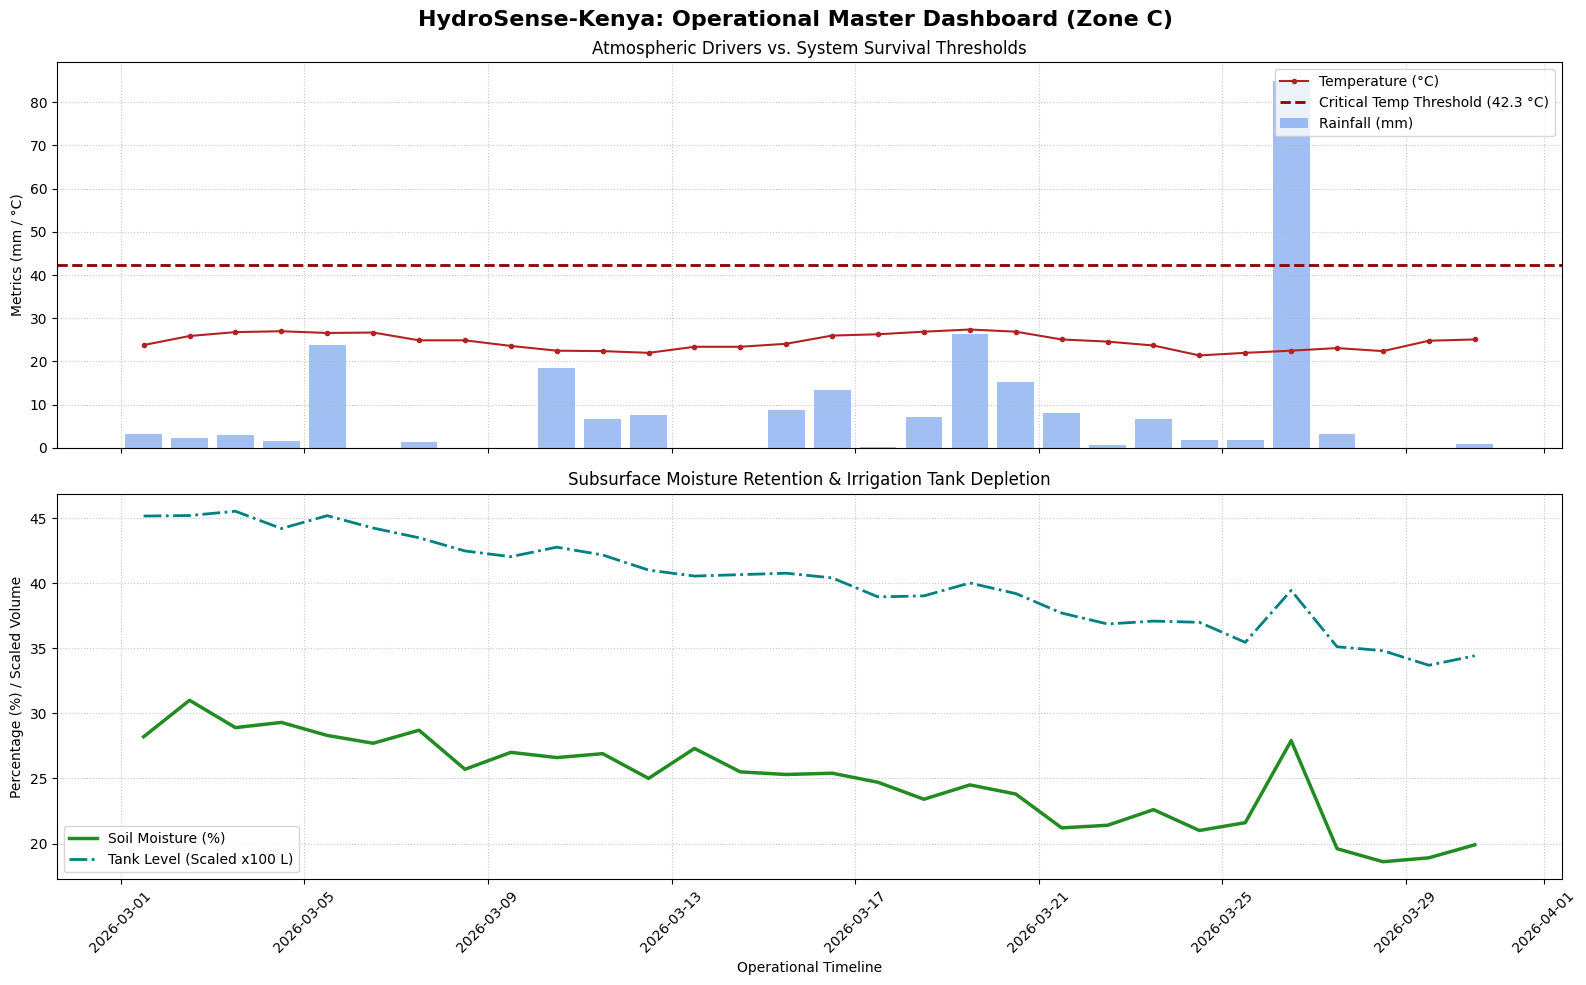

In [3]:
# Isolate a specific zone for high-fidelity visualization
zone_data = system_data[system_data['zone_id'] == 'Zone_C'].copy()

# Initialize the master dashboard layout
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('HydroSense-Kenya: Operational Master Dashboard (Zone C)', fontsize=16, fontweight='bold')

# --- TOP PLOT: Atmospheric Drivers & Computed Thresholds ---
axes[0].bar(zone_data['timestamp'], zone_data['rainfall_mm'], color='cornflowerblue', alpha=0.6, label='Rainfall (mm)')
axes[0].plot(zone_data['timestamp'], zone_data['temperature_c'], color='firebrick', marker='.', label='Temperature (°C)')

# Overlay the mathematically derived threshold from our numerical engine
axes[0].axhline(root_bisect, color='darkred', linestyle='--', linewidth=2, 
                label=f'Critical Temp Threshold ({root_bisect:.1f} °C)')

axes[0].set_title('Atmospheric Drivers vs. System Survival Thresholds', fontsize=12)
axes[0].set_ylabel('Metrics (mm / °C)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- BOTTOM PLOT: Subsurface Response & Infrastructure ---
# Scale the tank liters down by a factor of 100 so it plots cleanly on the same percentage axis
axes[1].plot(zone_data['timestamp'], zone_data['soil_moisture_pct'], color='forestgreen', 
             linewidth=2.5, label='Soil Moisture (%)')
axes[1].plot(zone_data['timestamp'], zone_data['tank_level_liters'] / 100, color='teal', 
             linestyle='-.', linewidth=2, label='Tank Level (Scaled x100 L)')

axes[1].set_title('Subsurface Moisture Retention & Irrigation Tank Depletion', fontsize=12)
axes[1].set_ylabel('Percentage (%) / Scaled Volume')
axes[1].set_xlabel('Operational Timeline')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle=':', alpha=0.7)

# Format the x-axis for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Render the final dashboard
plt.show()